<a href="https://colab.research.google.com/github/vitoriaayres/NOTEBOOKS_COMPILADOS/blob/main/MIA_Keyword_Cluster_wink.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install Unidecode

In [4]:
import numpy as np
import pandas as pd
import json
import re
import nltk.corpus
from unidecode import unidecode
from nltk import SnowballStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn import cluster

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.metrics import silhouette_samples, silhouette_score
from wordcloud import WordCloud
import folium
from branca.element import Figure

In [7]:
data = pd.read_excel('test.xlsx')
data.columns = map(str.lower, data.columns)

In [10]:
indicators= ['red', 'yellow', 'blue', 'orange', 'green', 'violet']
def indication_find(x):
  list_of_words= x.split(' ')
  out_data= []
  for word in list_of_words:
    if word.strip('.,!') in indicators:
      out_data.append(word)
  if len(out_data) ==0:
    return np.nan
  else:
    return out_data[0]
  return str(out_data)
data['colours']= data['keywords'].apply(indication_find)

In [11]:
data.tail()

,keywords,colours
6,notebook para programação,NaN
7,pc gamer barato,NaN
8,curso python,NaN
9,curso machine learning,NaN
10,machine learning python,NaN


In [15]:
corpus = data['keywords'].tolist()
corpus[0][0:447]

'iphone 17 preço'

In [16]:
def removeWords(listOfTokens, listOfWords):
    return [token for token in listOfTokens if token not in listOfWords]

def applyStemming(listOfTokens, stemmer):
  return [stemmer.stem(token) for token in listOfTokens]
def twoLetters(listOfTokens):
  twoLetterWord= []
  for token in listOfTokens:
    if len(token) <= 2 or len(token) >= 21:
      twoLetterWord.append(token)
  return twoLetterWord

In [38]:
_tfidf_vectorizer_instance = TfidfVectorizer()
X = _tfidf_vectorizer_instance.fit_transform(corpus)
tf_idf = pd.DataFrame(data=X.toarray(), columns=_tfidf_vectorizer_instance.get_feature_names_out())

final_df = tf_idf
print("{} rows".format(final_df.shape[0]))
final_df.T.nlargest(5, 0)

11 rows


,0,1,2,3,4,5,6,7,8,9,10
17,0.57735,0.457885,0.515049,0.000000,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.0
iphone,0.57735,0.457885,0.515049,0.000000,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.0
preço,0.57735,0.457885,0.000000,0.496131,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.0
barato,0.00000,0.000000,0.000000,0.000000,0.000000,0.57735,0.0,0.54484,0.0,0.0,0.0
celular,0.00000,0.000000,0.000000,0.000000,0.605159,0.00000,0.0,0.00000,0.0,0.0,0.0


In [19]:
final_df.T.nlargest(5,0)

,0,1,2,3,4,5,6,7,8,9,10
17,0.57735,0.457885,0.515049,0.000000,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.0
iphone,0.57735,0.457885,0.515049,0.000000,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.0
preço,0.57735,0.457885,0.000000,0.496131,0.000000,0.00000,0.0,0.00000,0.0,0.0,0.0
barato,0.00000,0.000000,0.000000,0.000000,0.000000,0.57735,0.0,0.54484,0.0,0.0,0.0
celular,0.00000,0.000000,0.000000,0.000000,0.605159,0.00000,0.0,0.00000,0.0,0.0,0.0


In [26]:
def run_KMeans(max_k, data):
  max_k += 1
  kmeans_results= dict()
  for k in range(2, max_k):
      kmeans = cluster.KMeans(n_clusters = k
                               , init = 'k-means++'
                               , n_init = 10
                               , tol = 0.0001
                               , random_state = 1
                               , algorithm = 'lloyd') # 'full' is deprecated, 'lloyd' is the new default
      kmeans_results.update({k: kmeans.fit(data)})
  return kmeans_results

In [30]:
def printAvg(avg_dict):
  for avg in sorted(avg_dict.keys(), reverse= True):
      print("Avg: {}\tK:{}".format(avg.round(4), avg_dict[avg]))

def plotSilhouette(df, n_clusters, kmeans_labels, silhouette_avg):
  fig, ax1= plt.subplots(1)
  fig.set_size_inches(8,6)
  ax1.set_xlim([-0.2, 1])
  ax1.set_ylim([0, len(df) + (n_clusters + 1) * 10])

  ax1.axvline(x=silhouette_avg, color= 'red', linestyle='--') # Alterado de '---' para '--'
  ax1.set_yticks([])
  ax1.set_xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
  plt.title(("Silhouette analysis for K = %d" % n_clusters), fontsize=10, fontweight='bold')

  y_lower= 10
  sample_silhouette_values= silhouette_samples(df, kmeans_labels)
  for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[kmeans_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
  plt.show()

def silhouette(kmeans_dict, df, plot=False):
    df = df.to_numpy()
    avg_dict = dict()
    for n_clusters, kmeans in kmeans_dict.items():
        kmeans_labels = kmeans.predict(df)
        silhouette_avg = silhouette_score(df, kmeans_labels)
        avg_dict.update( {silhouette_avg : n_clusters} )

        if(plot): plotSilhouette(df, n_clusters, kmeans_labels, silhouette_avg)

In [27]:
k= 10
kmeans_results= run_KMeans(k, final_df)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


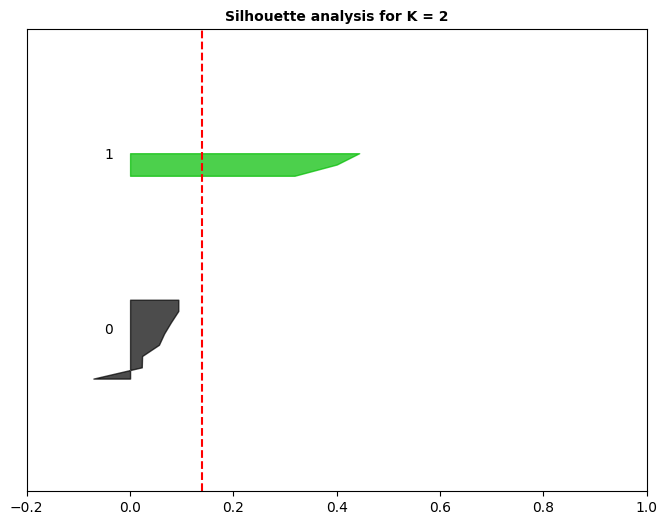

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


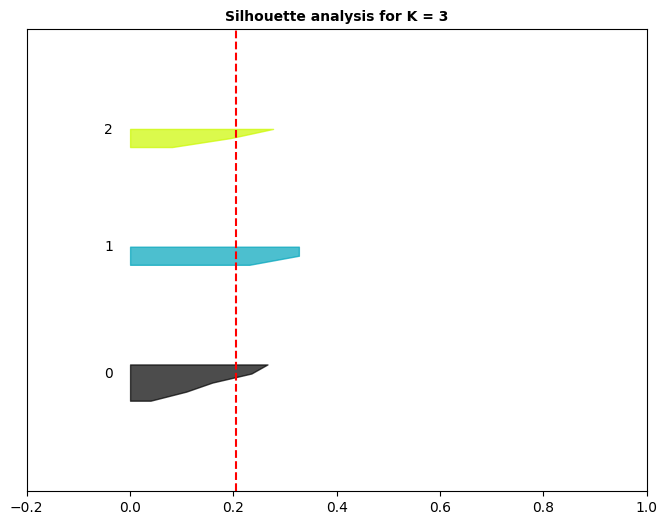

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


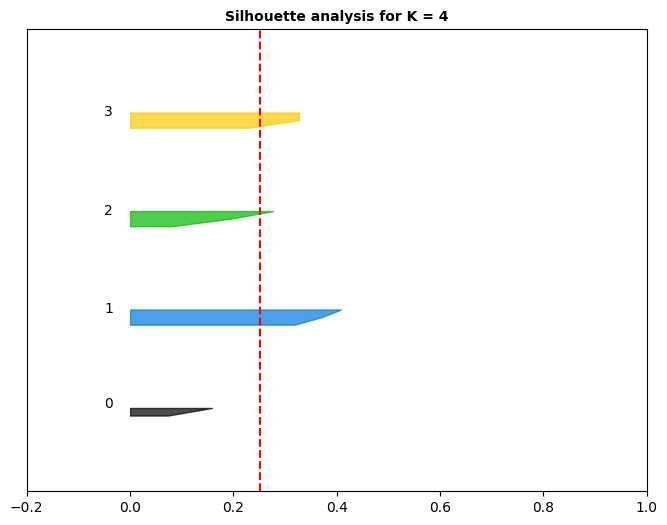

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


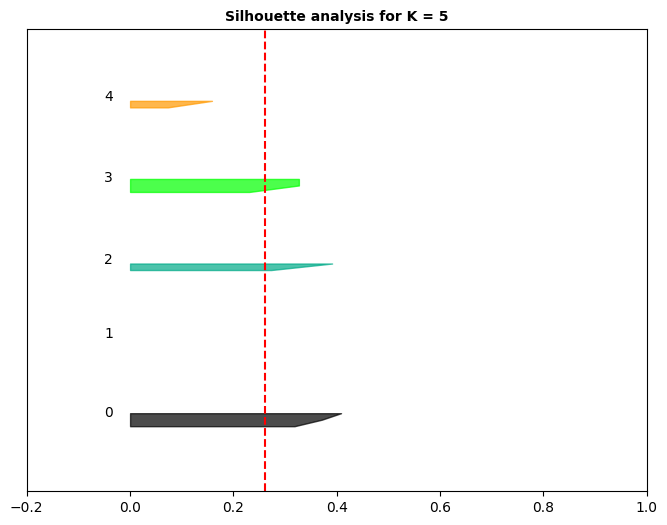

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


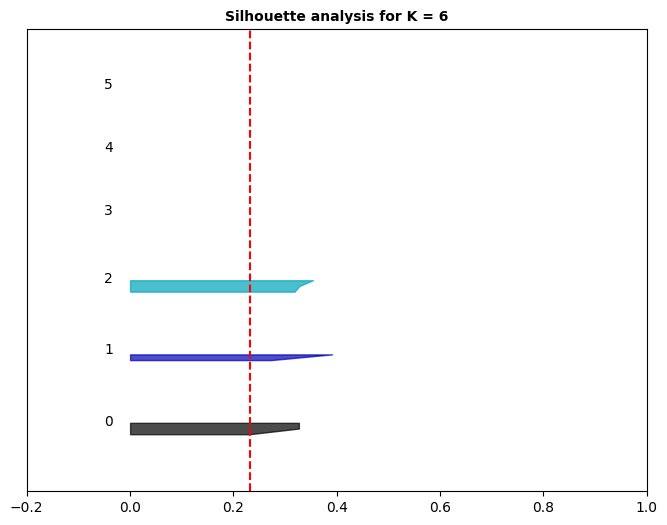

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


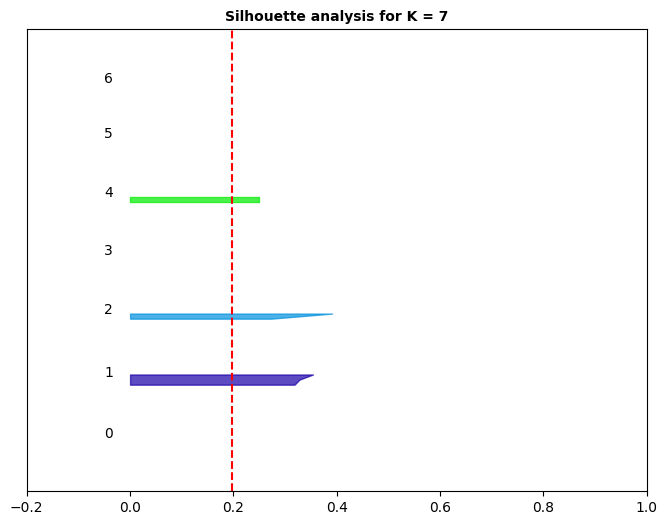

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


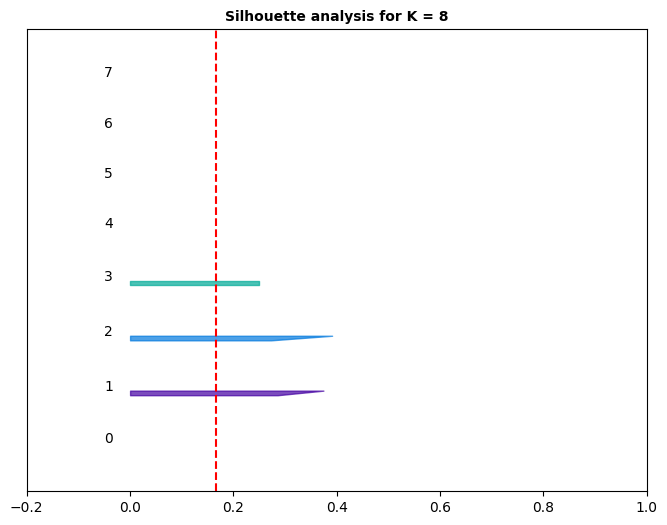

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


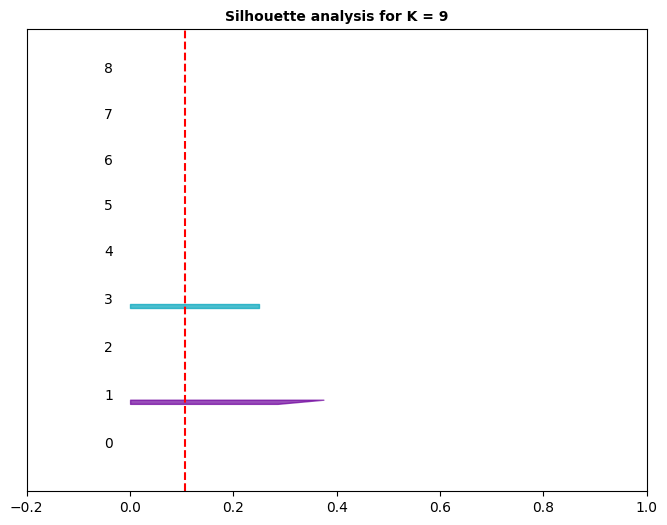

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


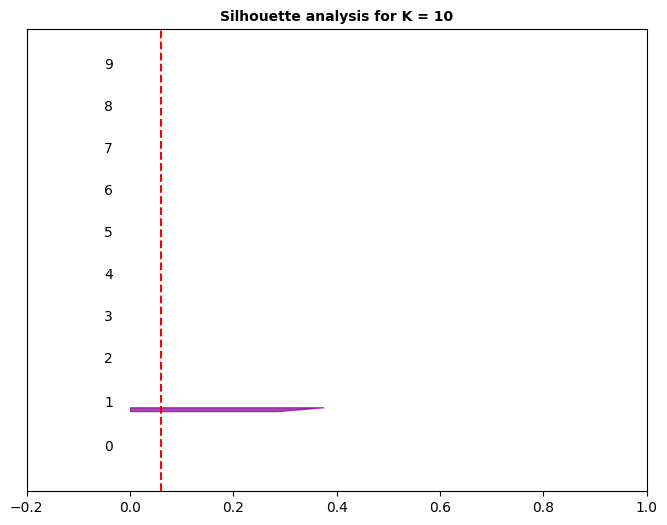

In [31]:
silhouette(kmeans_results, final_df, plot=True)

In [48]:
def get_top_features_cluster(tf_idf_array, prediction, n_feats, vectorizer_obj):
  labels= np.unique(prediction)
  dfs= []
  for label in labels:
    id_temp= np.where(prediction==label)
    x_means= np.mean(tf_idf_array[id_temp], axis=0)
    sorted_means= np.argsort(x_means)[::-1][:n_feats]
    features = vectorizer_obj.get_feature_names_out()
    best_features= [(features[i], x_means[i]) for i in sorted_means]
    df= pd.DataFrame(best_features, columns= ['features', 'score'])
    dfs.append(df)
  return dfs
def plotWords(dfs, n_feats):
  plt.figure(figsize=(8, 4))
  for i in range(0, len(dfs)):
    plt.title(("Most Common Words in Cluster {}".format(i)), fontsize=10, fontweight='bold')
    # Passando os dados diretamente como Series para evitar problemas de conversão de unidades
    sns.barplot(x = dfs[i][:n_feats]['score'] , y = dfs[i][:n_feats]['features'], orient = 'h')
    plt.show()

In [54]:
def controidsDict(centroids, index):
  a= centroids.T[index].sort_values(ascending=False).reset_index().values
  centroid_dict= dict()

  for i in range(0, len(a)):
    centroid_dict.update({a[i,0] : a[i,1]})
  return centroid_dict

def generateWordClouds(centroids):
  wordcloud= WordCloud(max_font_size= 100, background_color= 'white')
  for i in range(0, len(centroids)):
    centroid_dict= centroidsDict(centroids, i)
    wordcloud.generate_from_frequencies(centroid_dict)

    plt.figure()
    plt.title('cluster {}'.format(i))
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.show()